In [8]:
# Import required libraries for data handling, NLP preprocessing, and evaluation
import json
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load one chunk of the IMDB Review Dataset (part-04.json) downloaded from Kaggle
with open('/kaggle/input/imdb-review-dataset/part-04.json', 'r') as file:
    data = json.load(file)

In [10]:
# Build a pandas DataFrame from the loaded JSON records
df = pd.DataFrame([record for record in data])

In [11]:
# Inspect the available columns in the raw dataset
df.columns

Index(['review_id', 'reviewer', 'movie', 'rating', 'review_summary',
       'review_date', 'spoiler_tag', 'review_detail', 'helpful'],
      dtype='object')

In [12]:
# Drop columns that are not needed for this task, keep only 'rating' and 'review_detail'
df = df.drop(columns = ['review_id', 'reviewer','movie','review_summary',
       'review_date', 'spoiler_tag', 'helpful'])

In [13]:
# Preview the resulting DataFrame
df

,rating,review_detail
0,3,I watched The Pink Panther with Steve Martin r...
1,10,I have only just come in from seeing the film ...
2,8,One of the earliest Farces by John Lanting's T...
3,8,Another viewing for this original after being ...
4,10,"If you are into prophecy, the Rapture, the Tri..."
...,...,...
1018995,None,"I've seen first movie, which was great, and pe..."
1018996,1,Godsend is not the worst movie i have ever see...
1018997,None,Everyone ends up happy. The daughter is happy ...
1018998,10,"Sen to Chihiro no kamikakushi, or Spirited Awa..."


In [14]:
# Remove rows with missing values
df = df.dropna()
df

,rating,review_detail
0,3,I watched The Pink Panther with Steve Martin r...
1,10,I have only just come in from seeing the film ...
2,8,One of the earliest Farces by John Lanting's T...
3,8,Another viewing for this original after being ...
4,10,"If you are into prophecy, the Rapture, the Tri..."
...,...,...
1018993,10,"I Know you are thinking ""How can a show called..."
1018994,9,"Keaton was now out on his own, no longer worki..."
1018996,1,Godsend is not the worst movie i have ever see...
1018998,10,"Sen to Chihiro no kamikakushi, or Spirited Awa..."


In [15]:
# Download NLTK resources needed for stopword removal and lemmatization
nltk.download('stopwords')
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [16]:
# Manually extract the WordNet corpus archive (workaround for the Kaggle environment)
! unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()



  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.noun  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.noun  
  inflating: /usr/share/nltk_data/corpora/wordnet/adj.exc  


In [17]:
# Initialize the WordNet lemmatizer
lemmatizer = WordNetLemmatizer()

In [18]:
# Sort the DataFrame by rating (for inspection purposes)
df = df.sort_values(by="rating")

In [19]:
# Check how many reviews exist per rating value (class distribution)
df["rating"].value_counts()

rating
10    211184
8     123797
9     107059
7     101196
1      86258
6      73236
5      55337
4      42383
3      39650
2      37653
Name: count, dtype: int64

In [20]:
# Shift ratings to a 0-indexed range (1-10 -> 0-9) for a quick look at the distribution
a = df["rating"].apply(lambda x : int(x)-1)

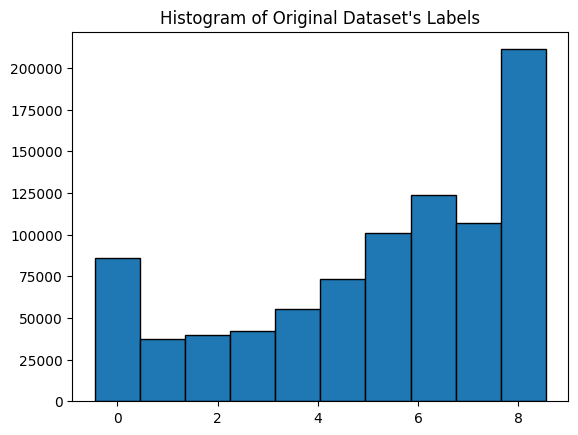

In [21]:
# Plot a histogram of the original (imbalanced) label distribution
plt.hist(a ,edgecolor = "black", align = "left")
plt.title("Histogram of Original Dataset's Labels")
plt.savefig("/kaggle/working/Histogram_of_Original_Dataset's_Labels")
plt.show()

In [22]:
# List the unique rating values present in the data
df["rating"].unique()

array(['1', '10', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [23]:
# Balance the classes: randomly sample 10,000 reviews for each rating value
ds = df.groupby('rating').sample(n=10000, random_state=63)

In [24]:
# Shift the sampled subset's ratings to 0-indexed labels (required by SparseCategoricalCrossentropy)
ds["rating"] = ds["rating"].apply(lambda x : int(x)-1)

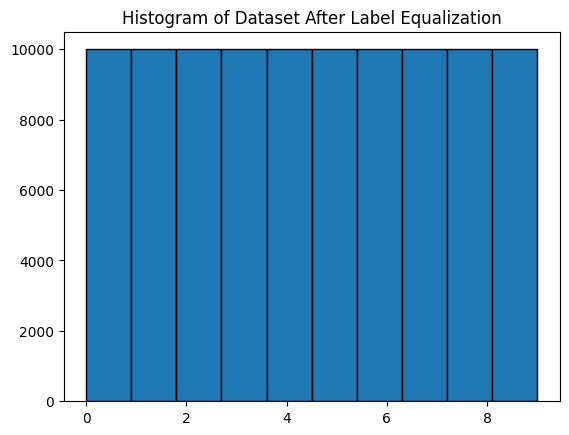

In [25]:
# Plot a histogram of the label distribution after class balancing
plt.hist(ds['rating'], edgecolor = "black")
plt.title('Histogram of Dataset After Label Equalization')
plt.savefig("/kaggle/working/Histogram_of_Dataset_After_Label_Equalization")
plt.show()

In [26]:
# Lowercase the review text and store it in a new 'content' column
ds["content"] = ds["review_detail"].str.lower()
ds.head()

,rating,review_detail,content
636224,0,The show went pretty bizarre and baseless shor...,the show went pretty bizarre and baseless shor...
793539,0,"Go watch paint dry instead., don't waste your ...","go watch paint dry instead., don't waste your ..."
803982,0,This is a GREAT comedy film.A great-great-grea...,this is a great comedy film.a great-great-grea...
550306,0,I'm a big fan of the show! but man this episod...,i'm a big fan of the show! but man this episod...
571297,0,"This episode really annoys. Yo yo, the fastest...","this episode really annoys. yo yo, the fastest..."


In [27]:
# Remove punctuation and digits from the review text
ds['content'] = ds['content'].astype(str)
ds['content'] = ds['content'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
ds['content'] = ds['content'].apply(lambda x: re.sub(r'\d+', '', x))

In [28]:
# Preview the cleaned text
ds.head()

,rating,review_detail,content
636224,0,The show went pretty bizarre and baseless shor...,the show went pretty bizarre and baseless shor...
793539,0,"Go watch paint dry instead., don't waste your ...",go watch paint dry instead dont waste your tim...
803982,0,This is a GREAT comedy film.A great-great-grea...,this is a great comedy filma greatgreatgreat c...
550306,0,I'm a big fan of the show! but man this episod...,im a big fan of the show but man this episode ...
571297,0,"This episode really annoys. Yo yo, the fastest...",this episode really annoys yo yo the fastest g...


In [29]:
# Tokenize the cleaned text into individual words
ds['tokens'] = ds['content'].str.split()
ds["tokens"].head()

636224    [the, show, went, pretty, bizarre, and, basele...
793539    [go, watch, paint, dry, instead, dont, waste, ...
803982    [this, is, a, great, comedy, filma, greatgreat...
550306    [im, a, big, fan, of, the, show, but, man, thi...
571297    [this, episode, really, annoys, yo, yo, the, f...
Name: tokens, dtype: object

In [30]:
# Remove English stopwords from the tokens
stop_words = set(stopwords.words('english'))
ds['tokens'] = ds['tokens'].apply(lambda x: [word for word in x if word not in stop_words])
ds['tokens'].head()

636224    [show, went, pretty, bizarre, baseless, short,...
793539    [go, watch, paint, dry, instead, dont, waste, ...
803982    [great, comedy, filma, greatgreatgreat, comedy...
550306    [im, big, fan, show, man, episode, horrible, c...
571297    [episode, really, annoys, yo, yo, fastest, gir...
Name: tokens, dtype: object

In [31]:
# Lemmatize the remaining tokens and join them back into a single string
ds["lemmatized_tokens"] = ds['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x]).apply(lambda x: ' '.join(x))
ds["lemmatized_tokens"].head()

636224    show went pretty bizarre baseless short due mo...
793539    go watch paint dry instead dont waste time you...
803982    great comedy filma greatgreatgreat comedy film...
550306    im big fan show man episode horrible change ch...
571297    episode really annoys yo yo fastest girl galax...
Name: lemmatized_tokens, dtype: object

In [32]:
# Convert the preprocessed text into TF-IDF feature vectors (top 1000 terms)
tfidf_vectorizer = TfidfVectorizer( max_features = 1000 ,min_df = 10, max_df = 0.9 ) 
tfidf_matrix = tfidf_vectorizer.fit_transform(ds["lemmatized_tokens"]) 

In [33]:
# Convert the TF-IDF sparse matrix into a DataFrame for easier handling
tfidf_df = pd.DataFrame(
    data = tfidf_matrix.toarray(), 
    columns = tfidf_vectorizer.get_feature_names_out(),
)

In [34]:
# Preview the TF-IDF feature DataFrame
tfidf_df.head()

,ability,able,absolutely,accent,across,act,acted,acting,action,actor,...,year,yes,yet,york,youll,young,younger,youre,youve,zombie
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.55718,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


In [35]:
# Note: 'rating' is not a TF-IDF feature column, so this returns an empty/NaN series (leftover/debug cell)
tfidf_df["rating"]

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
99995    0.0
99996    0.0
99997    0.0
99998    0.0
99999    0.0
Name: rating, Length: 100000, dtype: float64

In [36]:
# Show the target labels (ratings) corresponding to the balanced dataset
ds["rating"]

636224    0
793539    0
803982    0
550306    0
571297    0
         ..
22416     8
804103    8
391343    8
732824    8
937571    8
Name: rating, Length: 100000, dtype: int64

In [37]:
# Import Keras/TensorFlow components needed to build and train the ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.models import Model

In [38]:
# Define the ANN architecture: Dense + Dropout layers ending in a 10-class softmax output
inputs = Input(shape=(tfidf_df.shape[1],))

hidden = Dense(256, activation="relu")(inputs)
hidden = Dropout(0.3)(hidden)

hidden = Dense(128, activation="relu")(hidden)
hidden = Dropout(0.3)(hidden)

hidden = Dense(64, activation="relu")(hidden)
hidden = Dropout(0.3)(hidden)

hidden = Dense(32, activation="relu")(hidden)
hidden = Dropout(0.3)(hidden)

outputs = Dense(10, activation="softmax", name="output_layer")(hidden)

model = Model(inputs=inputs, outputs=outputs)

In [39]:
# Define the optimizer (Adam with a low learning rate) and the loss function
optimizer = Adam(0.0001)
loss = SparseCategoricalCrossentropy()

In [40]:
# Compile the model with the chosen optimizer, loss, and accuracy metric
model.compile(optimizer= optimizer, 
              loss= loss, 
              metrics=['accuracy'])

In [41]:
# Print a summary of the model architecture and parameter counts
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         256,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 299,818 (1.14 MB)

 Trainable params: 299,818 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Split the data into training (80%) and test (20%) sets
x_train, x_test, y_train, y_test = train_test_split(tfidf_df, ds["rating"], test_size=0.2, random_state=48)

In [43]:
# Define histogram bin edges covering the 10 rating classes
bins = [x for x in range (0,11)]
bins

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

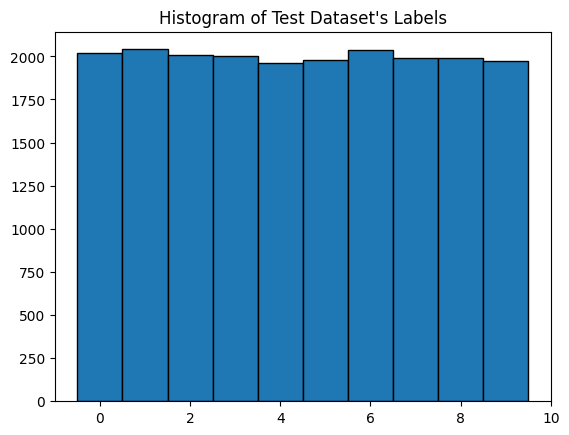

In [44]:
# Plot the label distribution of the test set to check it stayed balanced
plt.hist(y_test,bins = bins ,edgecolor = "black", align = "left")

plt.title("Histogram of Test Dataset's Labels")
plt.savefig("/kaggle/working/Histogram_of_Test_Dataset's_Labels")
plt.show()

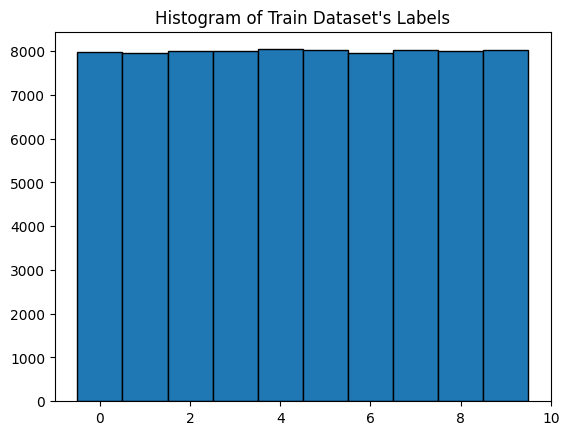

In [45]:
# Plot the label distribution of the training set to check it stayed balanced
plt.hist(y_train ,bins = bins ,edgecolor = "black", align = "left")
plt.title("Histogram of Train Dataset's Labels")
plt.savefig("/kaggle/working/Histogram_of_Train_Dataset's_Labels")
plt.show()

In [46]:
# Shuffle the training and test sets
x_test, y_test = shuffle(x_test, y_test, random_state=31)
x_train, y_train = shuffle(x_train, y_train, random_state=62)

In [47]:
# Set training hyperparameters: number of epochs and batch size
epochs = 200
batch_size = 32

In [48]:
# Train the ANN on the training data
model.fit(x_train, y_train, epochs = epochs, batch_size= batch_size)

Epoch 1/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.1123 - loss: 2.2939
Epoch 2/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2010 - loss: 2.0599
Epoch 3/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2366 - loss: 1.9643
Epoch 4/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2517 - loss: 1.9254
Epoch 5/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2591 - loss: 1.9008
Epoch 6/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2656 - loss: 1.8810
Epoch 7/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2762 - loss: 1.8600
Epoch 8/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2804 - loss: 1.8434
Epoch 9/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2868 - loss: 1.8220
Epoch 10/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2954 - loss: 1.7974
Epoch 11/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3042 - loss: 1.7660
Epoch 12/200
2500/

In [49]:
# Evaluate the trained model on the held-out test set (loss and accuracy)
model.evaluate(x_test, y_test, batch_size= batch_size)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2249 - loss: 5.4781


[5.463611125946045, 0.23010000586509705]

In [50]:
# Generate predictions on the test set in batches and rescale predictions/labels back to 1-10

prediction_list = []
true_value_list = []

x_t = np.array(x_test)
y_t = np.array(y_test)

# Verilerinizi batch boyutunda verebilirsiniz
batch_size = 32  # Batch boyutunu belirleyin

for i in range(0, x_t.shape[0], batch_size):
    batch_x = x_t[i:i+batch_size]  # Batch'lik giriş verisi
    batch_y = y_t[i:i+batch_size]  # Batch'lik gerçek etiketler

    # Batch halinde tahminler yap
    predictions = model.predict(batch_x, verbose=0)  # Batch tahminleri
    predictions = np.argmax(predictions, axis=1) + 1  # En yüksek olasılık tahminini al ve 1 ekle

    true_values = batch_y + 1  # Gerçek etiketlere 1 ekle

    # Listelere ekle
    prediction_list = np.append(prediction_list, predictions)
    true_value_list = np.append(true_value_list, true_values)

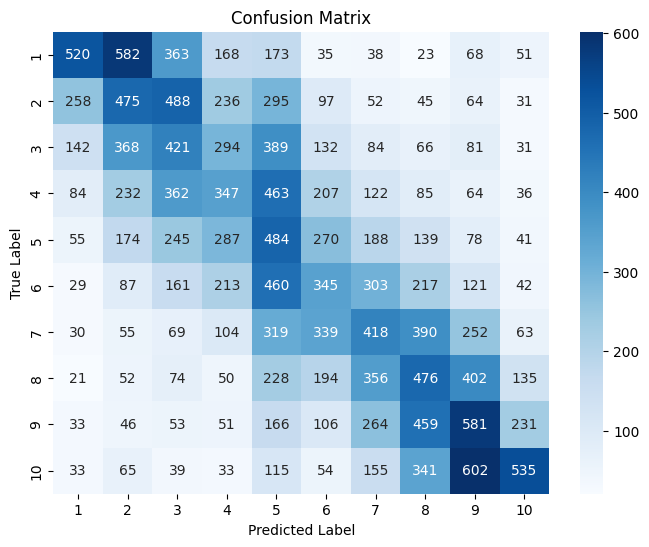

In [51]:
# Plot a confusion matrix comparing true vs. predicted ratings

cm = confusion_matrix(true_value_list, prediction_list)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(true_values), yticklabels=np.unique(true_values))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [52]:
# Compute 'closeness' metrics: % of predictions within +-1 of the true rating, and a distance-weighted score
difference = np.abs(prediction_list - true_value_list)
close_elements = difference <= 1
count_close = close_elements
print(count_close.sum()/len(true_value_list))

weights = 1 / (difference + 1)

print(weights.sum()/len(true_value_list))

0.5758
0.5150096825396824
